# TCR clonotype validation analysis

In [ ]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(ggExtra)
  library(patchwork)
  library(cowplot)
  library(ComplexHeatmap)
})

In [ ]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [ ]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/external/hayashi/annotated/hayashi_ms_hc_filtered.qs", nthreads = getOption("hpc.ncpus", 1))

### Program scores

In [5]:
gep.usage <- set_names("T") %>% 
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/external/hayashi/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/external/hayashi/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`


### TCR sequencing

In [6]:
tcr <- vroom::vroom(
  file = "../data/processed/external/hayashi/source/GSE291328_Processed_data_allTCR.csv.gz",
  num_threads = getOption("hpc.ncpus", 1),
  show_col_types = FALSE
)

CSF-enriched expanded clonotypes defined as per original study:
1. Number of cells in CSF with TCR clonotype > 1
2. Clonotype > 0.75% of CSF TCR repertoire
3. Clonotype CSF:blood TCR repertoire percentage ratio > 2

In [ ]:
enriched.clonotypes <- tcr %>%
  select(Patient_ID, MERGED_clonotypeID_imm, clonotype_PB_cell_count_imm, clonotype_CSF_cell_count_imm) %>%
  distinct() %>%
  group_by(Patient_ID) %>%
  mutate(
    PB_total_cells = sum(clonotype_PB_cell_count_imm),
    CSF_total_cells = sum(clonotype_CSF_cell_count_imm)
  ) %>%
  ungroup() %>%
  mutate(
    clonotype_PB_repertoire_percentage = if_else(PB_total_cells > 0, clonotype_PB_cell_count_imm / PB_total_cells * 100, 0),
    clonotype_CSF_repertoire_percentage = if_else(CSF_total_cells > 0, clonotype_CSF_cell_count_imm / CSF_total_cells * 100, 0),
    clonotype_CSF_PB_ratio = clonotype_CSF_repertoire_percentage / clonotype_PB_repertoire_percentage,
    clonotype_CSF_enriched = clonotype_CSF_cell_count_imm > 1 & clonotype_CSF_repertoire_percentage > 0.75 & clonotype_CSF_PB_ratio > 2
  ) %>%
  select(MERGED_clonotypeID_imm, clonotype_CSF_enriched) %>%
  distinct()
enriched.clonotypes

MERGED_clonotypeID_imm,clonotype_CSF_enriched
<chr>,<lgl>
26887_2427,FALSE
107735_53129,FALSE
55765_23659,FALSE
41944_77186,FALSE
65917_70404,FALSE
72610_74697,FALSE
47929_59065,FALSE
63853_1952,FALSE
79567_38158,FALSE


In [8]:
tcr.metadata <- tcr %>%
  select(cell_barcode_fmt, MERGED_clonotypeID_imm) %>%
  distinct() %>%
  left_join(enriched.clonotypes, by = "MERGED_clonotypeID_imm") %>%
  column_to_rownames("cell_barcode_fmt")
tcr.metadata

,MERGED_clonotypeID_imm,clonotype_CSF_enriched
,<chr>,<lgl>
CGATGTAGTTGAACTC-88418b_PB_uns,26887_2427,FALSE
GACGCGTCAAGCCGCT-91618a_PB_uns,107735_53129,FALSE
TTGACTTGTGTCCTCT-88618a_PB_uns,55765_23659,FALSE
ACTGAACAGCGTTTAC-87917a_PB_uns,41944_77186,FALSE
ACTGAACTCGCTAGCG-90218a_CSF_uns,65917_70404,FALSE
CAAGTTGCATGAACCT-90118a_PB_uns,72610_74697,FALSE
CCACGGAGTCCAGTAT-92418a_PB_uns,47929_59065,FALSE
ATCCACCGTGCTGTAT-88618a_PB_uns,63853_1952,FALSE
TTTACTGTCTTCGAGA-88818a_PB_uns,79567_38158,FALSE


# Compute UMAP

In [249]:
seu <- RunUMAP(
  seu,
  reduction = "integrated.rna",
  dims = 1:50,
  metric = "cosine",
  n.neighbors = 30L,
  min.dist = 0.3,
  spread = 1,
  n.epochs = 500L,
  return.model = TRUE
)

UMAP will return its model

23:24:38 UMAP embedding parameters a = 0.9922 b = 1.112

23:24:38 Read 108306 rows and found 50 numeric columns

23:24:38 Using Annoy for neighbor search, n_neighbors = 30

23:24:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

23:24:48 Writing NN index file to temp file /tmp/RtmpmAqI5h/file3e1e296c242ace

23:24:48 Searching Annoy index using 16 threads, search_k = 3000

23:24:52 Annoy recall = 100%

23:24:54 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 30

23:24:57 Initializing from normalized Laplacian + noise (using RSpectra)

23:25:05 Commencing optimization for 500 epochs, with 5346212 positive edges

23:26:59 Optimization finished



In [250]:
qs::qsave(
  seu,
  file = "../data/processed/external/hayashi/annotated/hayashi_ms_hc_filtered.qs",
  nthreads = getOption("hpc.ncpus", 1)
)

# Custom colour palettes

### Clusters

In [9]:
cluster.main.pal <- c(
  B = pals::brewer.reds(100)[90],
  DC = pals::brewer.greys(100)[90],
  Mono = pals::brewer.purples(100)[90],
  ILC = pals::brewer.oranges(100)[50],
  NK = pals::brewer.blues(100)[90],
  T = pals::brewer.greens(100)[90]
)

In [10]:
cluster.coarse.pal <- c(
  B_naive = pals::brewer.reds(5)[3],
  B_memory = pals::brewer.reds(5)[2],
  B_plasma = pals::brewer.reds(5)[4],
  DC_AXL_SIGLEC6 = pals::brewer.greys(5)[3],
  DC_conventional = pals::brewer.greys(5)[2],
  DC_plasmacytoid = pals::brewer.greys(5)[4],
  ILC = pals::brewer.oranges(100)[50],
  Mono_CD14 = pals::brewer.purples(5)[2],
  Mono_CD16 = pals::brewer.purples(5)[4],
  NK_CD56dim = pals::brewer.blues(5)[4],
  NK_CD56bright = pals::brewer.blues(5)[2],
  T_CD4_naive = pals::brewer.greens(10)[2],
  T_CD4_memory = pals::brewer.greens(10)[7],
  T_regulatory_naive = pals::brewer.greens(10)[5],
  T_regulatory_memory = pals::brewer.greens(10)[9],
  T_CD8_naive = pals::brewer.greens(10)[10],
  T_CD8_memory = pals::brewer.greens(10)[6],
  T_MAIT = pals::brewer.greens(10)[4],
  T_GD = pals::brewer.greens(10)[8],
  T_DN = pals::brewer.greens(10)[3]
)

In [11]:
cluster.pal <- c(cluster.main.pal, cluster.coarse.pal)

# Visualise integration

Inferred data type as 'discrete'. To override, set type explicitly.



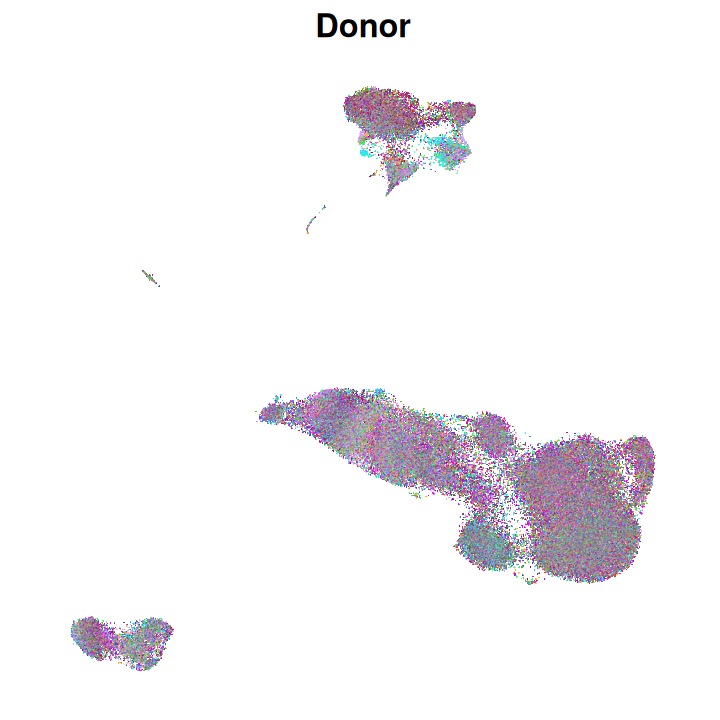

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "donor",
  cmap = pals::polychrome(15) |> set_names(sort(unique(seu$donor))),
  labs = list(title = "Donor"),
  show.legend = FALSE,
  rasterise = TRUE,
  size.adj = 3,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/hayashi_ms_hc_all_donor_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



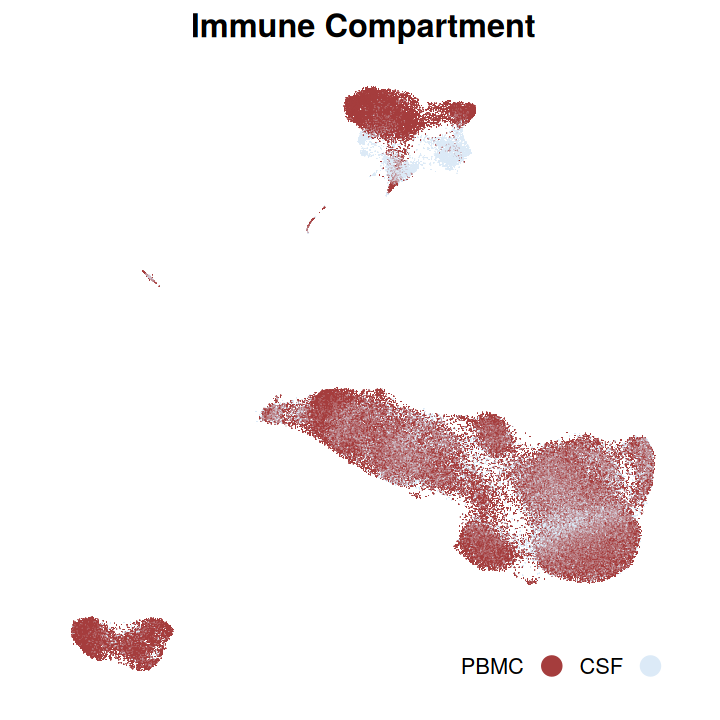

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "organ")) %>%
  mutate(organ = factor(organ, levels = c("PBMC", "CSF")))

plot <- embedding.plot(
  data,
  colour = "organ",
  cmap = c(PBMC = "#a53d3d", CSF = "#dceaf7"),
  labs = list(title = "Immune Compartment", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 3,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 1)) +
  inset.legend(location = "bottomright") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/hayashi_ms_hc_all_immune_compartment_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



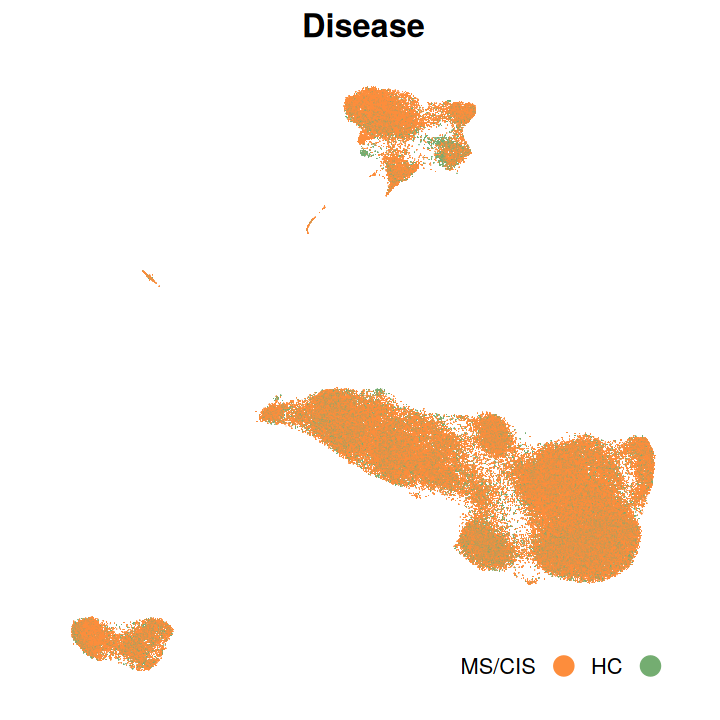

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "disease")) %>%
  mutate(disease = if_else(disease != "HC", "MS/CIS", "HC") |> factor(levels = c("MS/CIS", "HC")))

plot <- embedding.plot(
  data,
  colour = "disease",
  cmap = c(`MS/CIS` = "#FD8D3C", HC = "#74ad71"),
  labs = list(title = "Disease", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 3,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 1)) +
  inset.legend(location = "bottomright") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/hayashi_ms_hc_all_disease_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise cell types

Warning message in KernSmooth::bkde2D(coords, bandwidth = h, gridsize = c(50, 50)):
"Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'"
Warning message in KernSmooth::bkde2D(coords, bandwidth = h, gridsize = c(50, 50)):
"Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'"
Warning message in KernSmooth::bkde2D(coords, bandwidth = h, gridsize = c(50, 50)):
"Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'"
Warning message in KernSmooth::bkde2D(coords, bandwidth = h, gridsize = c(50, 50)):
"Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'"
Warning message in KernSmooth::bkde2D(coords, bandwidth = h, gridsize = c(50, 50)):
"Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'"
Warning message in KernSmooth::bkde2D(coords, bandwidth = h, gridsize = c(50, 50)):
"Binning grid too coarse for current (small) bandwidth: 

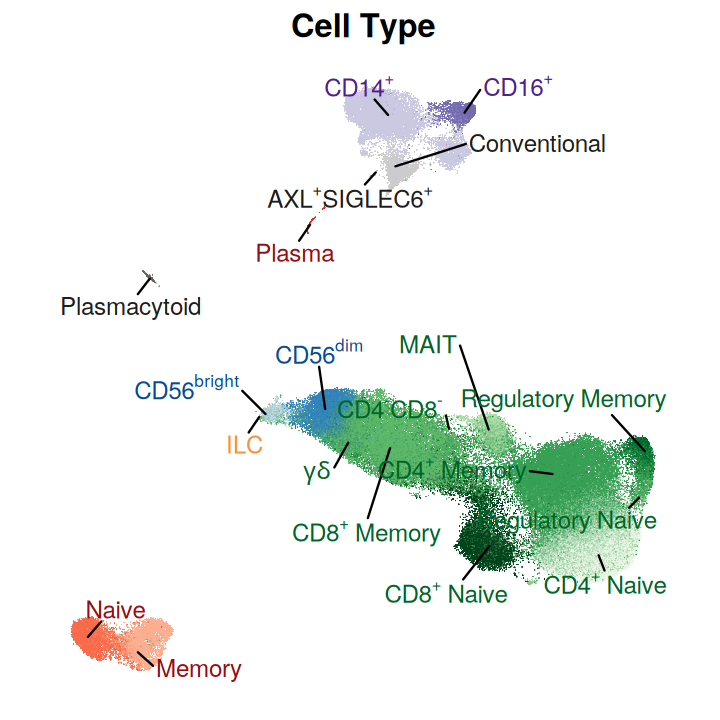

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      as.character(cluster_coarse),
      "B_naive" ~ "Naive",
      "B_memory" ~ "Memory",
      "B_plasma" ~ "Plasma",
      "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
      "DC_conventional" ~ "Conventional",
      "DC_plasmacytoid" ~ "Plasmacytoid",
      "ILC" ~ "ILC",
      "Mono_CD14" ~ "CD14^'+'",
      "Mono_CD16" ~ "CD16^'+'",
      "NK_CD56dim" ~ "CD56^dim",
      "NK_CD56bright" ~ "CD56^bright",
      "T_CD4_naive" ~ "CD4^'+'~Naive",
      "T_CD4_memory" ~ "CD4^'+'~Memory",
      "T_regulatory_naive" ~ "Regulatory~Naive",
      "T_regulatory_memory" ~ "Regulatory~Memory",
      "T_CD8_naive" ~ "CD8^'+'~Naive",
      "T_CD8_memory" ~ "CD8^'+'~Memory",
      "T_MAIT" ~ "MAIT",
      "T_GD" ~ "gamma*delta",
      "T_DN" ~ "CD4^'-'*CD8^'-'"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, labs = list(title = "Cell Type", colour = NULL), show.legend = FALSE, rasterise = TRUE, size.adj = 3, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/hayashi_ms_hc_all_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Subset to T cells

In [ ]:
# Subset to T cells only
sub <- subset(seu, subset = cluster_main == "T")
Idents(sub) <- "cluster_coarse"
sub <- AddMetaData(sub, metadata = tcr.metadata) # add TCR clonotype metadata

In [13]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["T"]])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


In [ ]:
# Keep only cells with TCR data available for downstream analysis
sub <- subset(sub, subset = MERGED_clonotypeID_imm %>%
  {
    !is.na(.)
  })

Warning message:
"Removing 45515 cells missing data for vars requested"


# Cross-clonotype group TARGET signature comparison

In [15]:
chosen.gep <- Features(sub[["GEP"]])[c(13, 20, 30)]
chosen.gep

[1] "Th1-like (CXCR3/CCL5/ITGA4)"             
[2] "Cytotoxic Inflammatory (GZMK/EOMES/IFNG)"
[3] "Activation Signalling (IER2/CD69/CD83)"

In [16]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

In [18]:
data <- FetchData(sub, vars = c("sample_id", "donor", "disease", "organ", "age", "sex", "cluster_coarse", "clonotype_CSF_enriched", "program_score")) %>%
  mutate(
    disease = factor(if_else(disease == "HC", "HC", "MS/CIS"), levels = c("MS/CIS", "HC")),
    organ = factor(organ, levels = c("PBMC", "CSF"))
  ) %>% 
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory"))

data.summary <- data %>%
  group_by(disease, organ, donor, sample_id, clonotype_CSF_enriched) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    donor = first(donor),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [19]:
model <- lmerTest::lmer(
  program_score ~ disease * organ * clonotype_CSF_enriched + age + sex + (1 | donor),
  data = data.summary
)

In [20]:
emm <- emmeans::emmeans(model, ~ disease * organ * clonotype_CSF_enriched, lmer.df = "Satterthwaite")

contrasts <- list(
  "MS/CIS PBMC CSF-enriched vs CSF-unenriched" = c(-1, 0, 0, 0, 1, 0, 0, 0),
  "HC PBMC CSF-enriched vs CSF-unenriched" = c(0, -1, 0, 0, 0, 1, 0, 0),
  "HC CSF CSF-enriched vs CSF-unenriched" = c(0, 0, 0, -1, 0, 0, 0, 1),
  "MS/CIS CSF CSF-enriched vs CSF-unenriched" = c(0, 0, -1, 0, 0, 0, 1, 0)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    ),
    disease = str_split_i(contrast, " ", 1),
    organ = str_split_i(contrast, " ", 2)
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(gsub(paste(disease, organ), "", contrast), " vs ", 1)),
    group2 = str_trim(str_split_i(gsub(paste(disease, organ), "", contrast), " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.55
  )

In [21]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,disease,organ,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<chr>,<chr>,<dbl>
MS/CIS PBMC CSF-enriched vs CSF-unenriched,0.203936057,0.02798890,33.90101,0.147049660,0.2608225,7.28632024,1.977896e-08,7.911584e-08,p = 7.91e-08 ***,MS/CIS,PBMC,CSF-enriched,CSF-unenriched,0.55
HC PBMC CSF-enriched vs CSF-unenriched,0.004187936,0.05383018,33.32983,-0.105289237,0.1136651,0.07779903,9.384531e-01,9.384531e-01,p = 0.938 ns,HC,PBMC,CSF-enriched,CSF-unenriched,0.55
HC CSF CSF-enriched vs CSF-unenriched,0.106134298,0.05383018,33.32983,-0.003342875,0.2156115,1.97165033,5.699678e-02,7.599570e-02,p = 0.076 .,HC,CSF,CSF-enriched,CSF-unenriched,0.55
MS/CIS CSF CSF-enriched vs CSF-unenriched,0.149598048,0.02575825,32.91635,0.097187443,0.2020087,5.80777306,1.714585e-06,3.429170e-06,p = 3.43e-06 ***,MS/CIS,CSF,CSF-enriched,CSF-unenriched,0.55


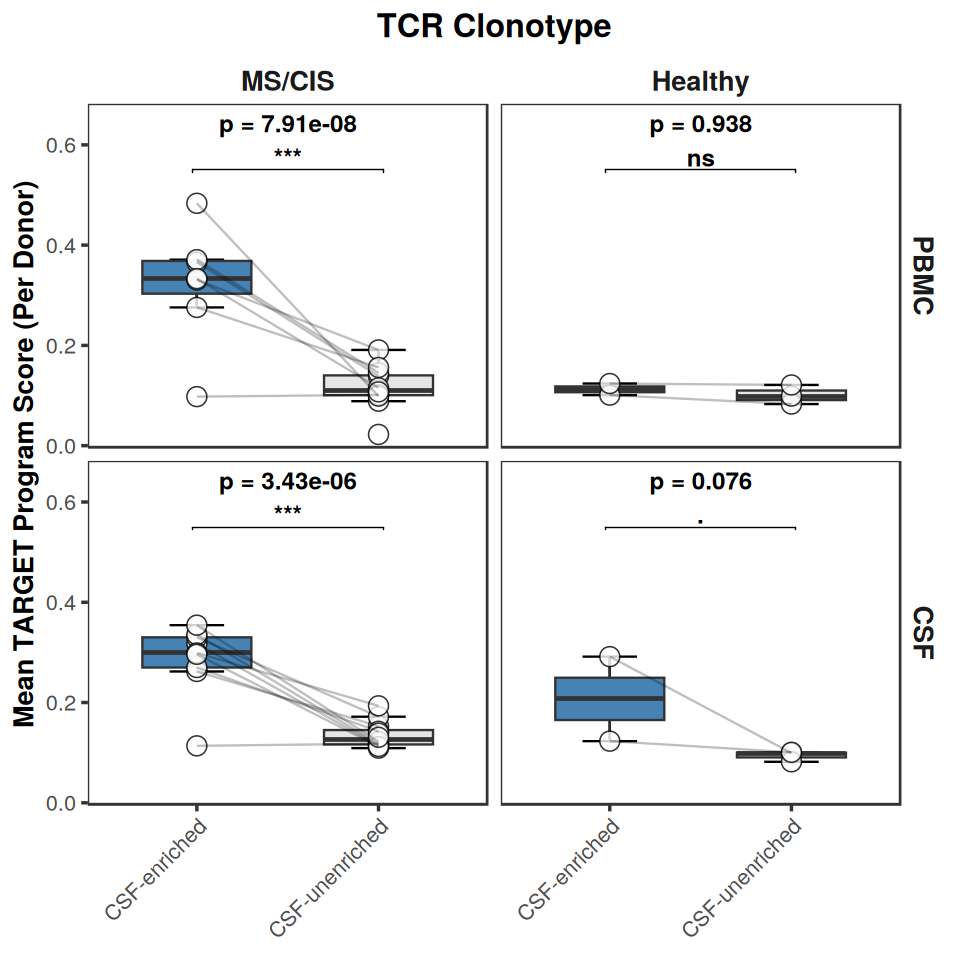

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 8)

ggplot(data = data.summary |> mutate(clonotype_CSF_enriched = if_else(clonotype_CSF_enriched, "CSF-enriched", "CSF-unenriched")), mapping = aes(x = clonotype_CSF_enriched, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = clonotype_CSF_enriched),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  facet_grid(
    rows = vars(fct_relevel(organ, "PBMC", "CSF")),
    cols = vars(factor(case_match(disease, "HC" ~ "Healthy", .default = disease), levels = c("MS/CIS", "Healthy")))
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.25))) +
  scale_fill_manual(values = c(`CSF-enriched` = "steelblue", `CSF-unenriched` = "grey90")) +
  labs(
    title = "TCR Clonotype",
    subtitle = NULL,
    x = NULL,
    y = "Mean TARGET Program Score (Per Donor)"
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 16, face = "bold"),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )

ggsave(
  filename = "../results/plots/hayashi_ms_hc_target_clonotype_group_boxplot.pdf",
  width = 8,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Session Info

In [245]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] reticulate_1.39.0  cowplot_1.1.3      patchwork_1.3.0    ggraph_2.2.1      
 [5] igraph_2.0.3       ggExtra_0.11.0     lubridate_1.9.3    forcats_1.0.0     
 [9] stringr_1.5.1      dplyr_1.1.4        purrr_1.0.2        readr_2.1.5       
[13] tidyr_1.3.1        tibble_3.2.1       ggplot2_3.5.1      tidyverse_2.0.0   
[17] future_1.34.0      Seurat_5.1.0       SeuratObject_5.0.2 sp_2.1-4          

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22       splines_4.3.3          later_1.3.2           
  [4] pbdZMQ_0.3-13          pol